# The Human Cost of Civilian Targeting
## 02 — Exploratory Data Analysis

**Domanda centrale:** *How has violence against civilians changed globally between 2021 and 2025, and where has humanitarian risk become most concentrated?*

Questo notebook analizza RQ1, RQ2, RQ3 e RQ5. La RQ4 sugli attori è intenzionalmente esclusa in questa fase.

### Perimetro analitico

L'analisi usa **tutti gli eventi disponibili**: gli anni 2021–2024 sono completi, mentre il **2025 è un anno parziale** e termina il 25 agosto. Di conseguenza, i totali annuali del 2025 non devono essere confrontati direttamente con quelli degli anni completi. Nei grafici temporali il 2025 è indicato con un asterisco.

Le `fatalities` sono stime delle morti riportate nelle fonti per l'evento. Nei casi di targeting diretto possono generalmente rappresentare civili o manifestanti uccisi, ma ACLED segnala eccezioni e incertezza: per prudenza usiamo l'espressione **reported fatalities in civilian-targeting events**. La prioritizzazione finale è un **proxy relativo basato su ACLED**, non un indice umanitario ufficiale né una stima della probabilità individuale di subire violenza.

Riferimenti metodologici: [ACLED Codebook](https://acleddata.com/methodology/acled-codebook) · [Civilian targeting variable](https://acleddata.com/knowledge-base/guide-to-2023-acled-column-changes/) · [Fatalities methodology](https://acleddata.com/methodology/fatalities).

## 1. Setup e caricamento

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests
import seaborn as sns
from IPython.display import Image, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

NAVY = "#183B56"
CORAL = "#E76F51"
TEAL = "#2A9D8F"
GOLD = "#E9C46A"
LIGHT_GREY = "#D9E2E8"

In [2]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "data" / "processed" / "acled_civilian_targeting_2021_2025.parquet"
EXTERNAL_DIR = PROJECT_DIR / "data" / "external"
TABLE_DIR = PROJECT_DIR / "data" / "analysis"
FIGURE_DIR = PROJECT_DIR / "outputs" / "eda_figures"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError("Esegui prima 01_acled_data_cleaning.ipynb.")

df = pd.read_parquet(DATA_PATH)
analysis_df = df.copy()
analysis_end_date = analysis_df["event_date"].max()
partial_year = int(analysis_end_date.year)
partial_year_fraction = (analysis_end_date.dayofyear / (366 if analysis_end_date.is_leap_year else 365))

def save_figure(fig, filename):
    fig.savefig(FIGURE_DIR / f"{filename}.png", bbox_inches="tight", facecolor="white")
    fig.savefig(FIGURE_DIR / f"{filename}.svg", bbox_inches="tight", facecolor="white")

print(f"Dataset completo: {len(df):,} eventi")
print(f"Eventi analizzati: {len(analysis_df):,}")
print(f"Paesi: {analysis_df['country'].nunique():,}")
print(f"Periodo: {analysis_df['event_date'].min():%d/%m/%Y}–{analysis_end_date:%d/%m/%Y}")
print(f"Attenzione: {partial_year} è un anno parziale ({partial_year_fraction:.1%} dell'anno osservato).")

Dataset completo: 251,579 eventi
Eventi analizzati: 251,579
Paesi: 190
Periodo: 01/01/2021–25/08/2025
Attenzione: 2025 è un anno parziale (64.9% dell'anno osservato).


In [3]:
# Controlli necessari prima delle aggregazioni.
assert not analysis_df.empty
assert analysis_df["year"].isin(range(2021, 2026)).all()
assert analysis_df["event_id_cnty"].is_unique
assert analysis_df["fatalities"].notna().all()
assert analysis_df["fatalities"].ge(0).all()
assert analysis_df["event_date"].min() == pd.Timestamp("2021-01-01")
assert analysis_end_date == pd.Timestamp("2025-08-25")
assert (
    analysis_df.loc[analysis_df["year"].lt(partial_year)]
    .groupby("year")["event_date"].apply(lambda dates: dates.dt.month.nunique()).eq(12).all()
)
print("✓ Dataset analitico valido: 2021–2024 completi, 2025 parziale fino al 25 agosto.")

✓ Dataset analitico valido: 2021–2024 completi, 2025 parziale fino al 25 agosto.


## 2. Overview globale

Prima delle singole RQ osserviamo l'evoluzione globale usando tutti i dati disponibili. Il 2025 è mostrato, ma marcato come parziale.

In [4]:
global_year = (
    analysis_df.groupby("year", observed=True)
    .agg(
        events=("event_id_cnty", "size"),
        fatalities=("fatalities", "sum"),
        fatal_events=("event_had_fatalities", "sum"),
    )
    .reset_index()
)
global_year["lethality_rate_pct"] = 100 * global_year["fatal_events"] / global_year["events"]
global_year["coverage"] = np.where(global_year["year"].eq(partial_year), "Partial through 25 Aug", "Full year")
display(global_year)
global_year.to_csv(TABLE_DIR / "global_year_available_period.csv", index=False)

,year,events,fatalities,fatal_events,lethality_rate_pct,coverage
0,2021,41510,44645,23200,55.89,Full year
1,2022,51356,55704,28660,55.81,Full year
2,2023,54735,71692,29134,53.23,Full year
3,2024,60181,78960,32059,53.27,Full year
4,2025,43797,52967,22716,51.87,Partial through 25 Aug


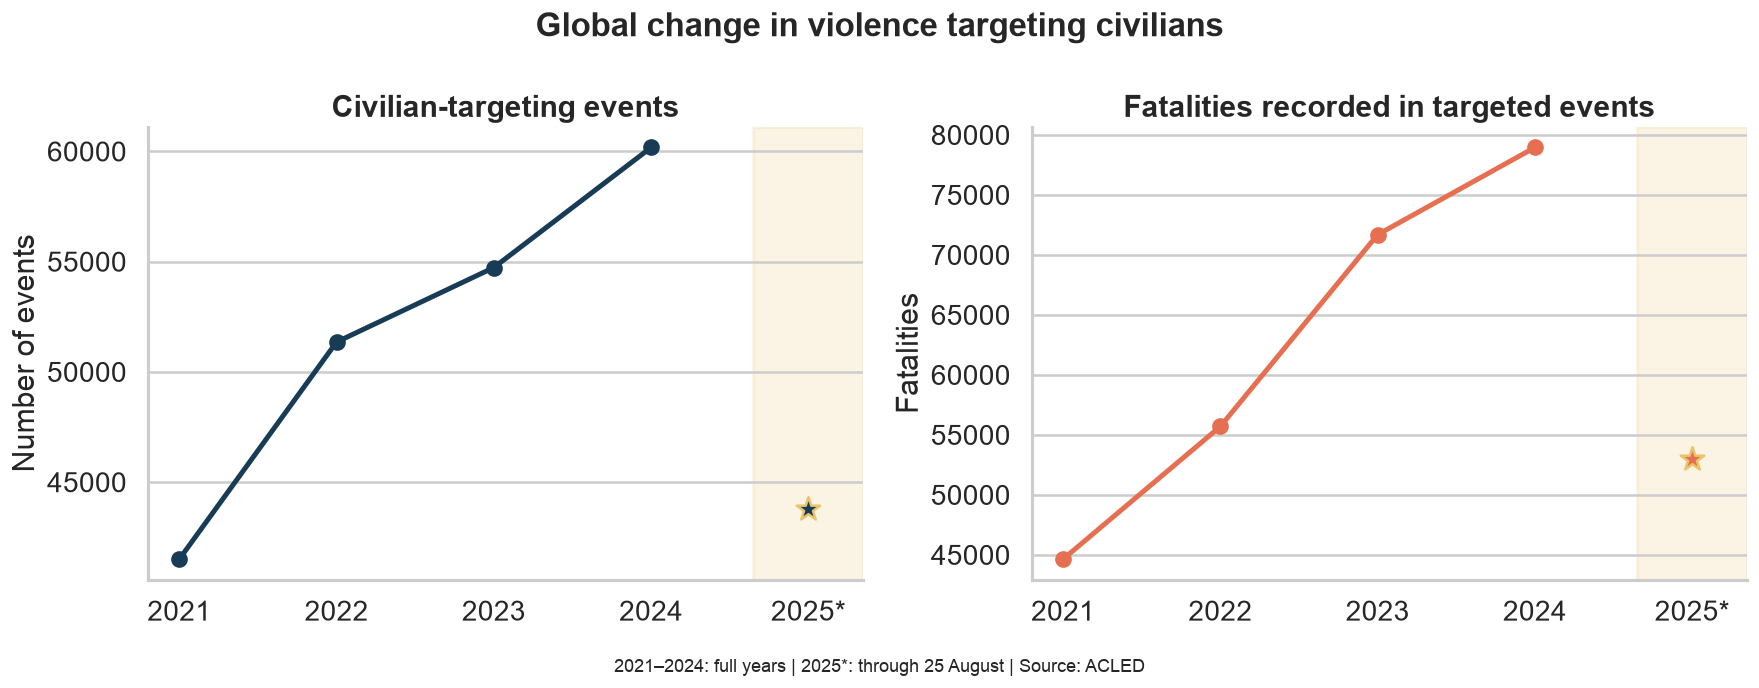

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

full_year_data = global_year.loc[global_year["year"].lt(partial_year)]
partial_year_data = global_year.loc[global_year["year"].eq(partial_year)].iloc[0]

axes[0].plot(full_year_data["year"], full_year_data["events"], marker="o", linewidth=3, color=NAVY)
axes[0].scatter(partial_year, partial_year_data["events"], marker="*", s=220, color=NAVY, edgecolor=GOLD, linewidth=1.5, zorder=4)
axes[0].set(title="Civilian-targeting events", xlabel="", ylabel="Number of events")
axes[0].ticklabel_format(style="plain", axis="y")

axes[1].plot(full_year_data["year"], full_year_data["fatalities"], marker="o", linewidth=3, color=CORAL)
axes[1].scatter(partial_year, partial_year_data["fatalities"], marker="*", s=220, color=CORAL, edgecolor=GOLD, linewidth=1.5, zorder=4)
axes[1].set(title="Fatalities recorded in targeted events", xlabel="", ylabel="Fatalities")
axes[1].ticklabel_format(style="plain", axis="y")

for ax in axes:
    ax.set_xticks(global_year["year"])
    ax.set_xticklabels(["2021", "2022", "2023", "2024", "2025*"])
    ax.axvspan(2024.65, 2025.35, color=GOLD, alpha=0.18, zorder=0)
    ax.set_xlim(2020.8, 2025.35)
    ax.grid(axis="x", visible=False)

fig.suptitle("Global change in violence targeting civilians", fontsize=20, fontweight="bold")
fig.text(0.5, -0.02, "2021–2024: full years | 2025*: through 25 August | Source: ACLED", ha="center", fontsize=11)
fig.tight_layout()
save_figure(fig, "01_global_trend")
plt.show()

### Context visualization — una geografia globale del fenomeno

Prima del confronto regionale, la mappa mostra dove si accumulano gli eventi nel mondo. Non introduce ancora una classifica di rischio: serve a rendere immediatamente visibili scala globale, concentrazioni e continuità transfrontaliere. Il colore rappresenta conteggi assoluti su scala logaritmica, così anche i valori intermedi restano leggibili.

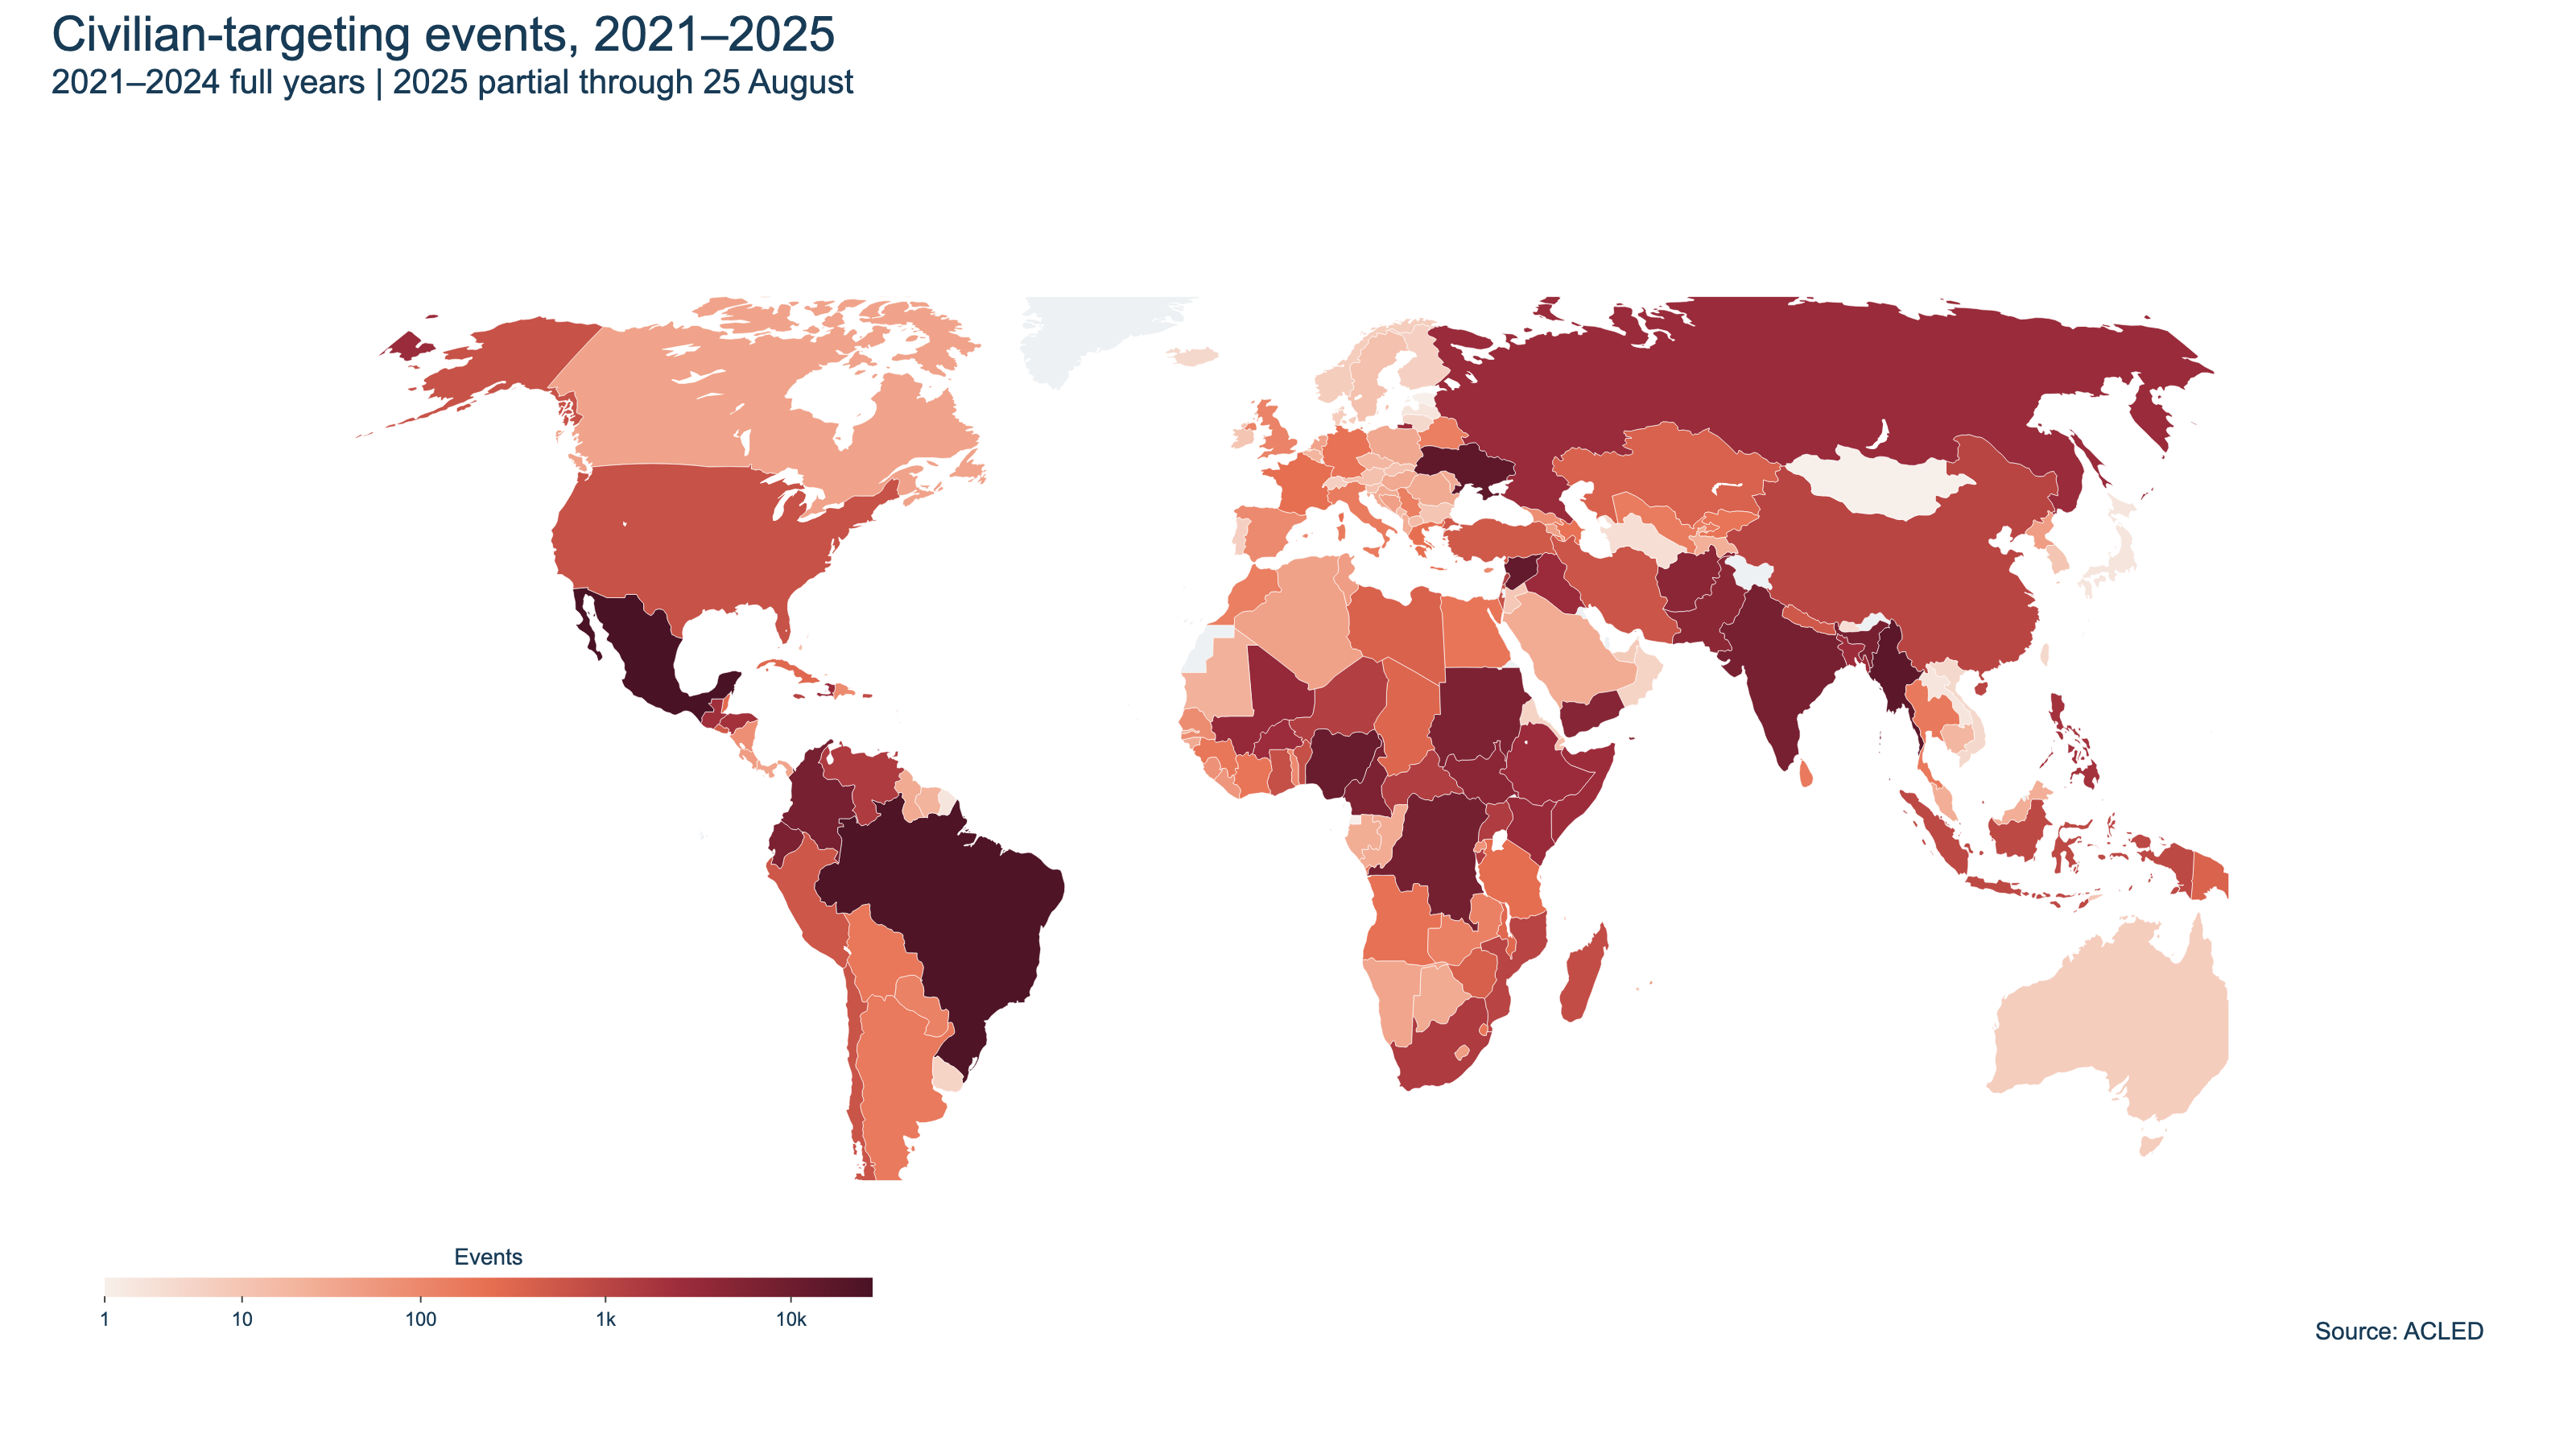

Mapped country/territory units: 186 of 190
Units without a map polygon:


,country,events
1,Akrotiri and Dhekelia,1
77,Indian Ocean,81
90,Kosovo,76
109,Mediterranean Sea,9


In [6]:
country_map = (
    analysis_df.groupby(["country", "iso3"], observed=True, dropna=False)
    .agg(
        events=("event_id_cnty", "size"),
        reported_fatalities=("fatalities", "sum"),
    )
    .reset_index()
)
country_map["log_events"] = np.log10(country_map["events"] + 1)
mappable_countries = country_map.loc[country_map["iso3"].notna()].copy()
unmapped_units = country_map.loc[country_map["iso3"].isna(), ["country", "events"]].copy()
country_map.to_csv(TABLE_DIR / "country_map_available_period.csv", index=False)

map_fig = px.choropleth(
    mappable_countries,
    locations="iso3",
    color="log_events",
    hover_name="country",
    custom_data=["events", "reported_fatalities"],
    color_continuous_scale=["#F7EFEA", "#F3B49D", CORAL, "#9D2C3B", "#4A1225"],
    projection="natural earth",
    title=(
        "Civilian-targeting events, 2021–2025"
        "<br><sup>2021–2024 full years | 2025 partial through 25 August</sup>"
    ),
)
map_fig.update_traces(
    marker_line_color="white",
    marker_line_width=0.35,
    hovertemplate=(
        "<b>%{hovertext}</b><br>Events: %{customdata[0]:,}"
        "<br>Reported fatalities: %{customdata[1]:,}<extra></extra>"
    ),
)
map_fig.update_geos(
    showframe=False, showcoastlines=False, showland=True, landcolor="#EEF1F3",
    showocean=True, oceancolor="white", bgcolor="white",
    domain={"x": [0, 1], "y": [0.16, 0.90]},
    lataxis_range=[-60, 85],
    projection_scale=1.23,
)
map_fig.update_coloraxes(
    colorbar={
        "title": {"text": "Events", "side": "top"},
        "tickvals": np.log10(np.array([1, 10, 100, 1_000, 10_000]) + 1),
        "ticktext": ["1", "10", "100", "1k", "10k"],
        "orientation": "h",
        "x": 0.02, "xanchor": "left",
        "y": 0.02, "yanchor": "bottom",
        "len": 0.32, "thickness": 12,
        "ticks": "outside", "ticklen": 4,
    }
)
map_fig.update_layout(
    width=1_600, height=900, margin={"l": 24, "r": 24, "t": 110, "b": 48},
    paper_bgcolor="white", font={"family": "Arial", "color": NAVY},
    title={"font": {"size": 30}, "x": 0.02, "y": 0.965, "yanchor": "top"},
    annotations=[{
        "text": "Source: ACLED", "showarrow": False,
        "xref": "paper", "yref": "paper",
        "x": 0.98, "y": 0.02, "xanchor": "right", "yanchor": "bottom",
        "font": {"size": 15, "color": NAVY},
    }],
)
map_fig.write_html(FIGURE_DIR / "02_global_context_map.html", include_plotlyjs="cdn")
map_fig.write_image(FIGURE_DIR / "02_global_context_map.png", scale=2)
map_fig.write_image(FIGURE_DIR / "02_global_context_map.svg")
display(Image(filename=str(FIGURE_DIR / "02_global_context_map.png"), width=1_100))
print(f"Mapped country/territory units: {len(mappable_countries):,} of {len(country_map):,}")
if not unmapped_units.empty:
    print("Units without a map polygon:")
    display(unmapped_units)

## 3. RQ1 — Quali regioni registrano più eventi?

Confrontiamo il numero di eventi per regione e anno usando tutti i dati disponibili. La heatmap mostra valori assoluti: misura la concentrazione degli eventi registrati, non il rischio pro capite. La colonna 2025* è parziale e va letta separatamente dagli anni completi.

In [21]:
region_year = (
    analysis_df.groupby(["region", "year"], observed=True)
    .agg(
        events=("event_id_cnty", "size"),
        fatalities=("fatalities", "sum"),
        fatal_events=("event_had_fatalities", "sum"),
    )
    .reset_index()
)
region_total = (
    region_year.groupby("region", observed=True)[["events", "fatalities"]]
    .sum()
    .sort_values("events", ascending=False)
)
region_year.to_csv(TABLE_DIR / "region_year_available_period.csv", index=False)
region_total.to_csv(TABLE_DIR / "region_total_available_period.csv")

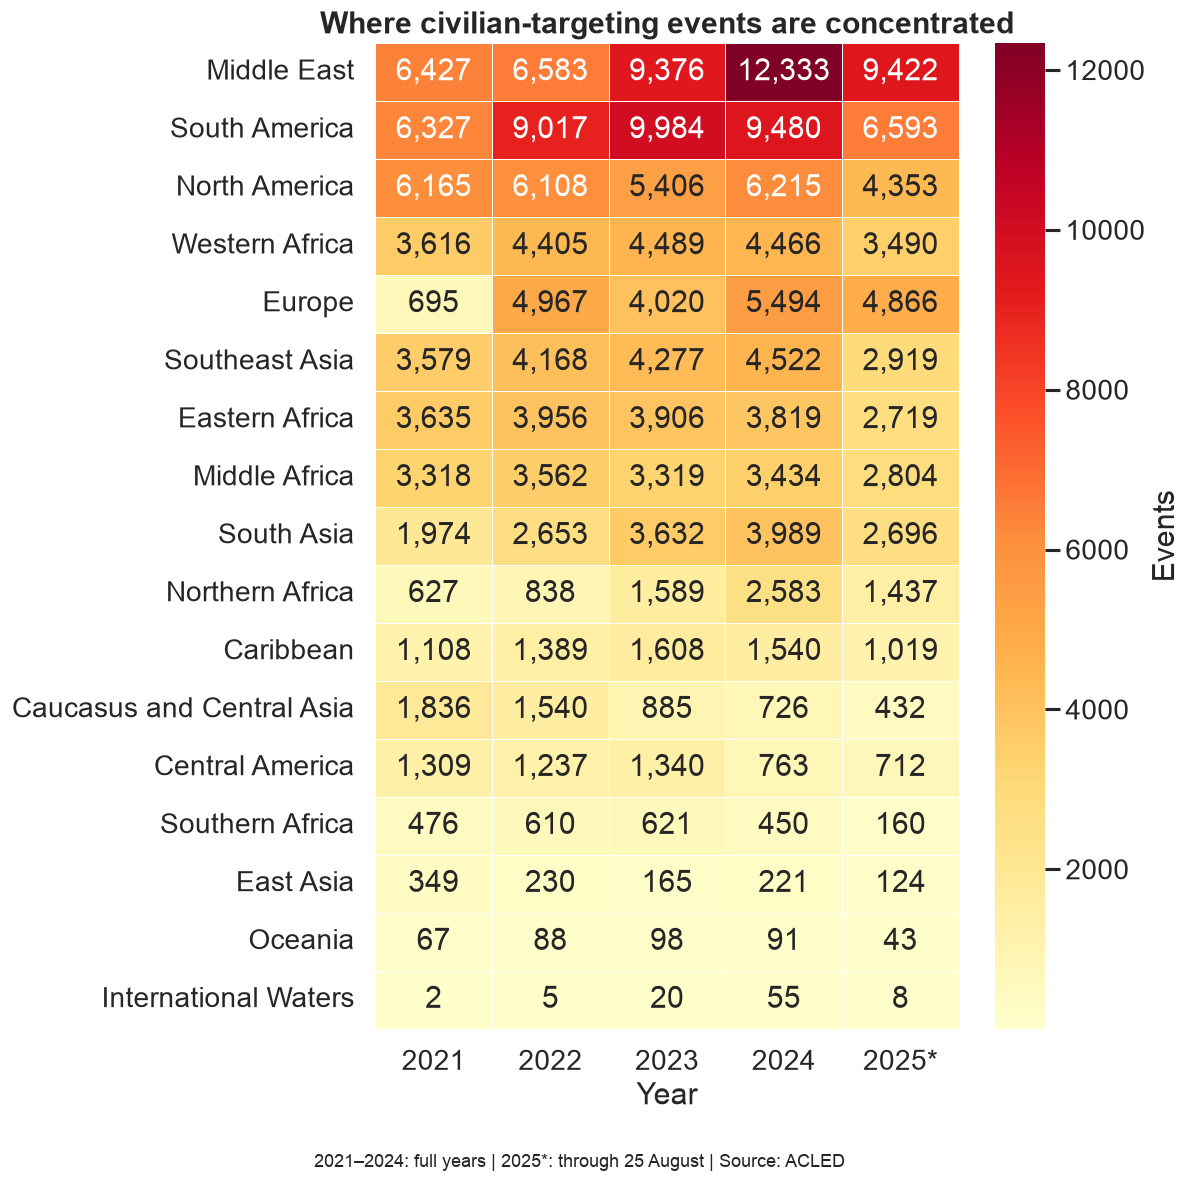

In [22]:
region_order = region_total.index.tolist()
event_heatmap = (
    region_year.pivot(index="region", columns="year", values="events")
    .reindex(region_order)
    .fillna(0)
    .astype(float)
)
event_heatmap.columns = [str(year) if year != partial_year else f"{year}*" for year in event_heatmap.columns]

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    event_heatmap, cmap="YlOrRd", annot=True, fmt=",.0f",
    linewidths=0.6, cbar_kws={"label": "Events"}, ax=ax,
)
ax.set(title="Where civilian-targeting events are concentrated", xlabel="Year", ylabel="")
fig.text(0.5, 0.01, "2021–2024: full years | 2025*: through 25 August | Source: ACLED", ha="center", fontsize=11)
fig.tight_layout(rect=[0, 0.03, 1, 1])
save_figure(fig, "02_region_events_heatmap")
plt.show()

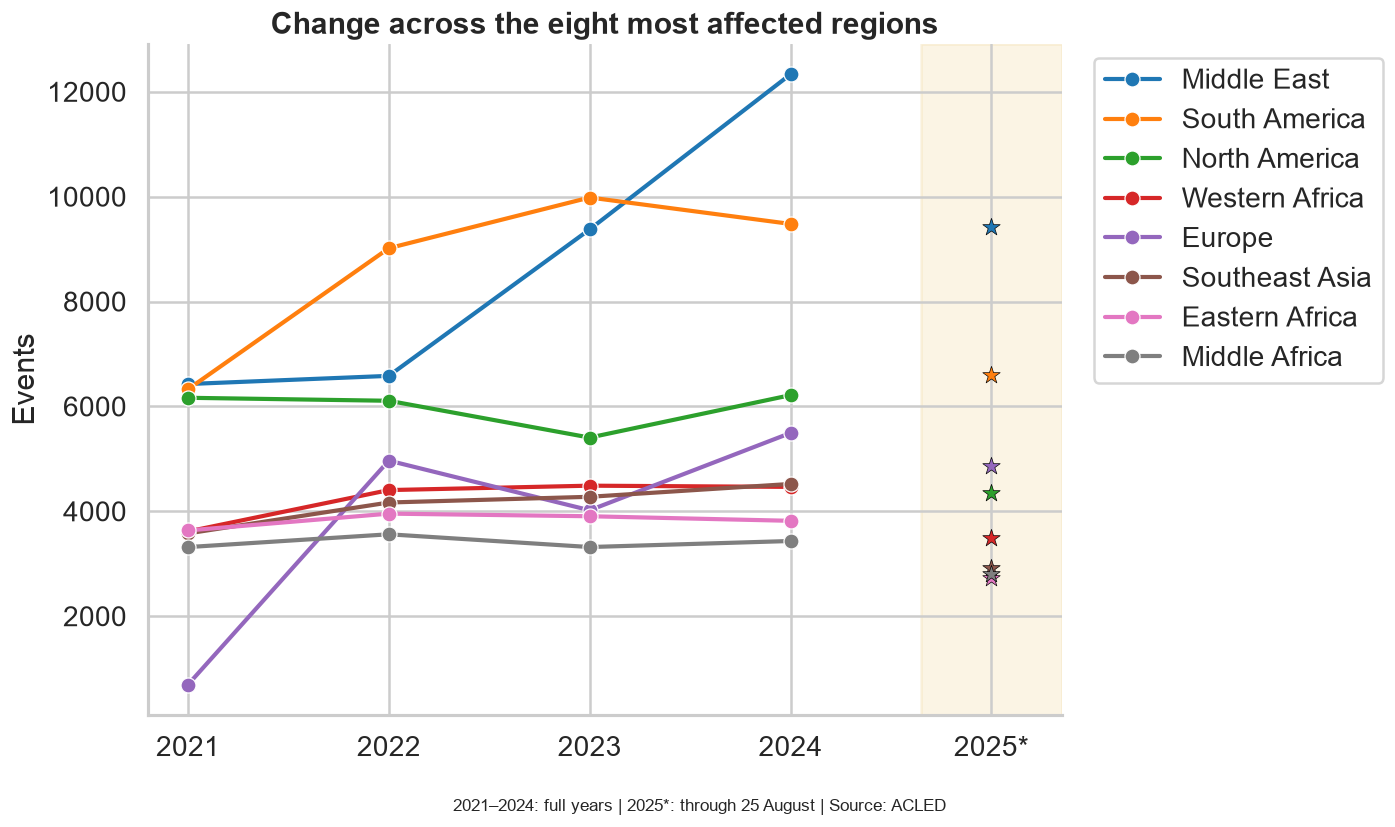

In [9]:
top_regions = region_total.head(8).index
plot_data = region_year.loc[region_year["region"].isin(top_regions)].copy()
region_palette = dict(zip(top_regions, sns.color_palette("tab10", len(top_regions))))

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=plot_data.loc[plot_data["year"].lt(partial_year)],
    x="year", y="events", hue="region", hue_order=top_regions,
    marker="o", linewidth=2.5, palette=region_palette, ax=ax,
)
for region in top_regions:
    partial_point = plot_data.loc[
        plot_data["region"].eq(region) & plot_data["year"].eq(partial_year)
    ]
    ax.scatter(
        partial_point["year"], partial_point["events"], marker="*", s=120,
        color=region_palette[region], edgecolor="black", linewidth=0.4, zorder=4,
    )
ax.set(title="Change across the eight most affected regions", xlabel="", ylabel="Events")
ax.set_xticks(sorted(analysis_df["year"].unique()))
ax.set_xticklabels(["2021", "2022", "2023", "2024", "2025*"])
ax.axvspan(2024.65, 2025.35, color=GOLD, alpha=0.18, zorder=0)
ax.set_xlim(2020.8, 2025.35)
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.text(0.5, 0.01, "2021–2024: full years | 2025*: through 25 August | Source: ACLED", ha="center", fontsize=10)
fig.tight_layout(rect=[0, 0.03, 1, 1])
save_figure(fig, "03_top_regions_trend")
plt.show()

### Commento ai risultati

Nel periodo disponibile, il **Middle East** registra il numero complessivo più alto di eventi (44.141), seguito da **South America** (41.401) e **North America** (28.247). Guardando soltanto gli anni completi, il Middle East cresce da 6.427 eventi nel 2021 a 12.333 nel 2024. Anche l'Europa aumenta nettamente, da 695 a 5.494 eventi, sebbene la variazione percentuale sia amplificata dal valore iniziale basso. South America raggiunge il massimo nel 2023 e resta su livelli elevati nel 2024; North America è invece più stabile. Entro il 25 agosto 2025 il Middle East registra già 9.422 eventi, ma questo totale non è direttamente confrontabile con quelli annuali completi.

**Interpretazione corretta:** la concentrazione degli eventi si è spostata soprattutto verso Middle East ed Europe, ma questi sono conteggi assoluti ACLED. Non misurano il rischio per abitante né dimostrano che ogni evento abbia la stessa gravità. Il 2025 è incluso soltanto fino al 25 agosto e deve essere presentato come dato provvisorio, non come evidenza di un calo rispetto al 2024.

## 4. RQ2 — I paesi con più eventi sono anche quelli con più fatalità?

Per ogni paese distinguiamo frequenza, fatalità totali e distribuzione della letalità. Media e mediana sono entrambe incluse perché pochi eventi estremamente letali possono alzare molto la media.

In [10]:
country_summary = (
    analysis_df.groupby(["region", "country", "iso3"], observed=True, dropna=False)
    .agg(
        events=("event_id_cnty", "size"),
        total_fatalities=("fatalities", "sum"),
        mean_fatalities=("fatalities", "mean"),
        median_fatalities=("fatalities", "median"),
        max_fatalities=("fatalities", "max"),
        fatal_events=("event_had_fatalities", "sum"),
        high_fatality_events=("fatalities", lambda values: values.ge(10).sum()),
    )
    .reset_index()
)
country_summary["lethality_rate"] = country_summary["fatal_events"] / country_summary["events"]
country_summary["low_sample_flag"] = country_summary["events"].lt(20)
event_fatality_rank_correlation = country_summary["events"].rank().corr(
    country_summary["total_fatalities"].rank()
)

display(country_summary.sort_values("events", ascending=False).head(15))
display(country_summary.sort_values("total_fatalities", ascending=False).head(15))
print(f"Spearman rank correlation, events vs fatalities: {event_fatality_rank_correlation:.2f}")

,region,country,iso3,events,total_fatalities,mean_fatalities,median_fatalities,max_fatalities,fatal_events,high_fatality_events,lethality_rate,low_sample_flag
121,North America,Mexico,MEX,27553,30489,1.11,1.00,20,21653,26,0.79,False
140,South America,Brazil,BRA,23830,20893,0.88,1.00,8,18424,0,0.77,False
114,Middle East,Palestine,PSE,19903,50602,2.54,0.00,471,7161,1361,0.36,False
163,Southeast Asia,Myanmar,MMR,16282,15830,0.97,0.00,200,8120,122,0.50,False
94,Europe,Ukraine,UKR,15310,11826,0.77,0.00,400,5363,108,0.35,False
116,Middle East,Syria,SYR,13360,10596,0.79,0.00,108,5962,106,0.45,False
186,Western Africa,Nigeria,NGA,11166,18734,1.68,1.00,225,5801,370,0.52,False
102,Middle Africa,Democratic Republic of Congo,COD,7908,17741,2.24,1.00,205,5195,356,0.66,False
142,South America,Colombia,COL,7721,6917,0.90,1.00,11,5335,1,0.69,False
153,South Asia,India,IND,7481,2573,0.34,0.00,26,2147,6,0.29,False


,region,country,iso3,events,total_fatalities,mean_fatalities,median_fatalities,max_fatalities,fatal_events,high_fatality_events,lethality_rate,low_sample_flag
114,Middle East,Palestine,PSE,19903,50602,2.54,0.00,471,7161,1361,0.36,False
121,North America,Mexico,MEX,27553,30489,1.11,1.00,20,21653,26,0.79,False
140,South America,Brazil,BRA,23830,20893,0.88,1.00,8,18424,0,0.77,False
186,Western Africa,Nigeria,NGA,11166,18734,1.68,1.00,225,5801,370,0.52,False
102,Middle Africa,Democratic Republic of Congo,COD,7908,17741,2.24,1.00,205,5195,356,0.66,False
163,Southeast Asia,Myanmar,MMR,16282,15830,0.97,0.00,200,8120,122,0.50,False
127,Northern Africa,Sudan,SDN,6295,15702,2.49,1.00,200,3684,394,0.59,False
94,Europe,Ukraine,UKR,15310,11826,0.77,0.00,400,5363,108,0.35,False
42,Eastern Africa,Ethiopia,ETH,2690,10950,4.07,1.00,338,1945,276,0.72,False
116,Middle East,Syria,SYR,13360,10596,0.79,0.00,108,5962,106,0.45,False


Spearman rank correlation, events vs fatalities: 0.92


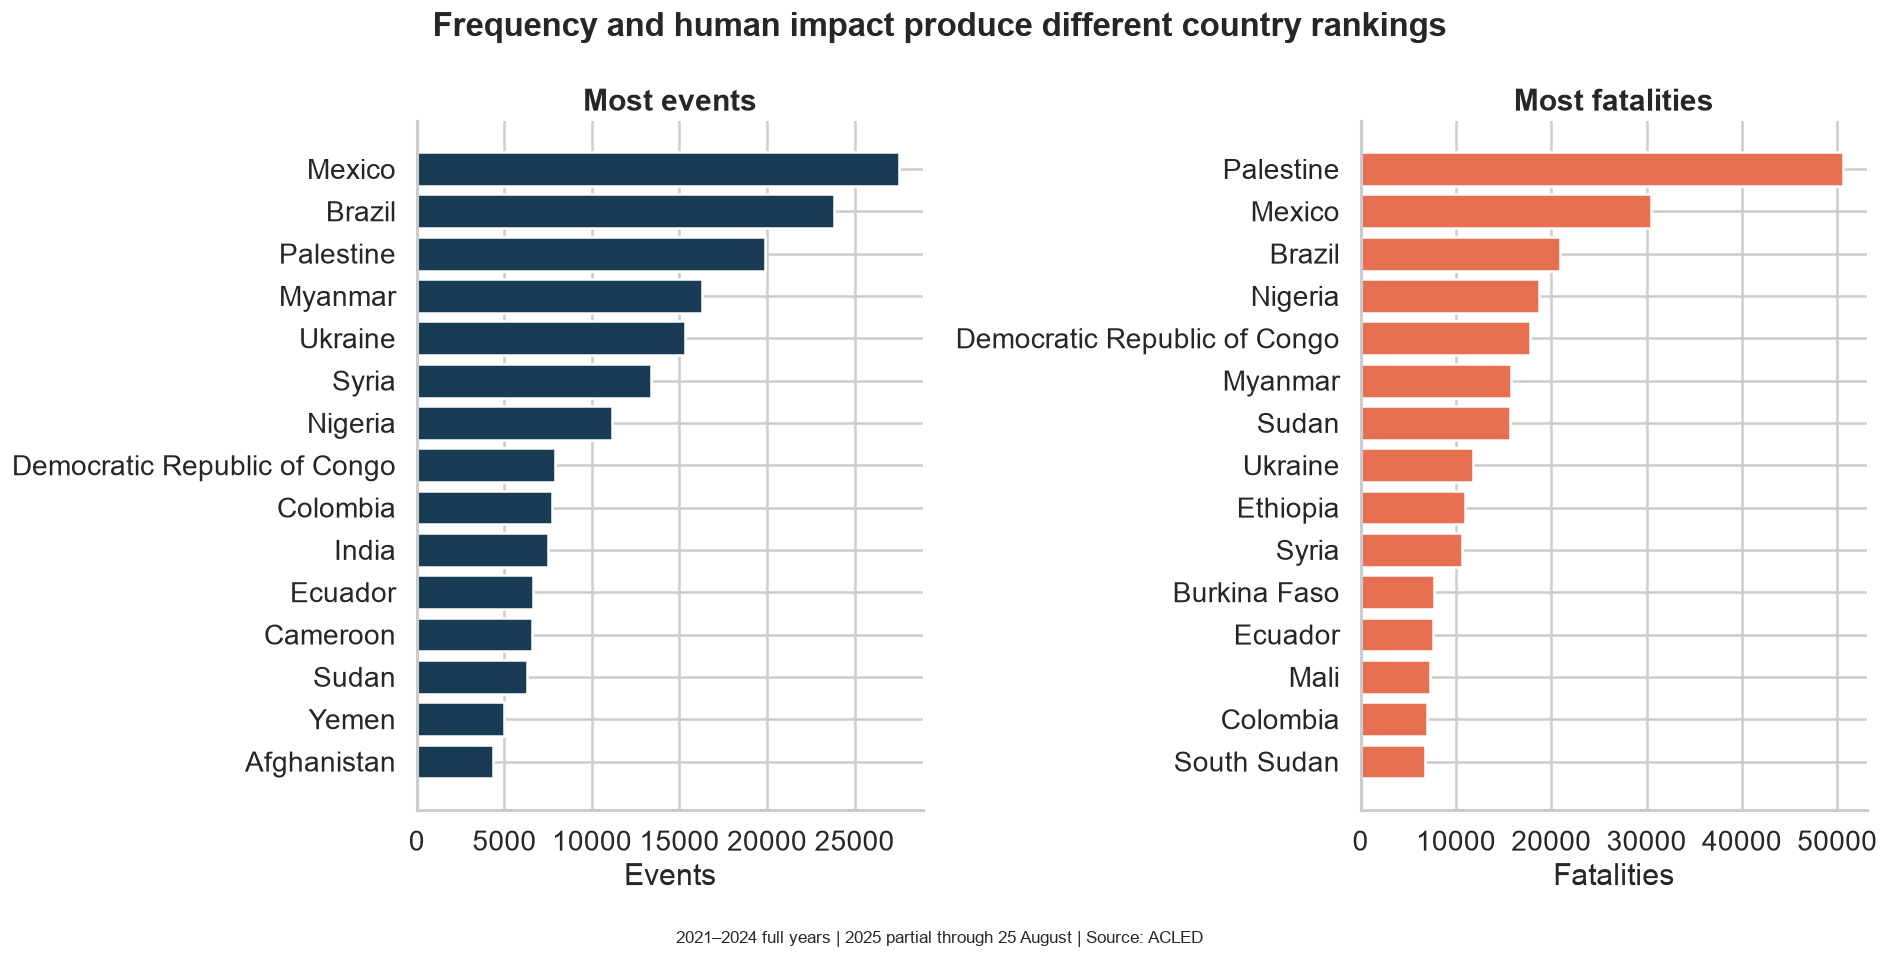

In [11]:
top_n = 15
top_events = country_summary.nlargest(top_n, "events").sort_values("events")
top_fatalities = country_summary.nlargest(top_n, "total_fatalities").sort_values("total_fatalities")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].barh(top_events["country"], top_events["events"], color=NAVY)
axes[0].set(title="Most events", xlabel="Events", ylabel="")
axes[1].barh(top_fatalities["country"], top_fatalities["total_fatalities"], color=CORAL)
axes[1].set(title="Most fatalities", xlabel="Fatalities", ylabel="")
fig.suptitle("Frequency and human impact produce different country rankings", fontsize=20, fontweight="bold")
fig.text(0.5, 0.01, "2021–2024 full years | 2025 partial through 25 August | Source: ACLED", ha="center", fontsize=10)
fig.tight_layout(rect=[0, 0.03, 1, 1])
save_figure(fig, "04_country_rankings")
plt.show()

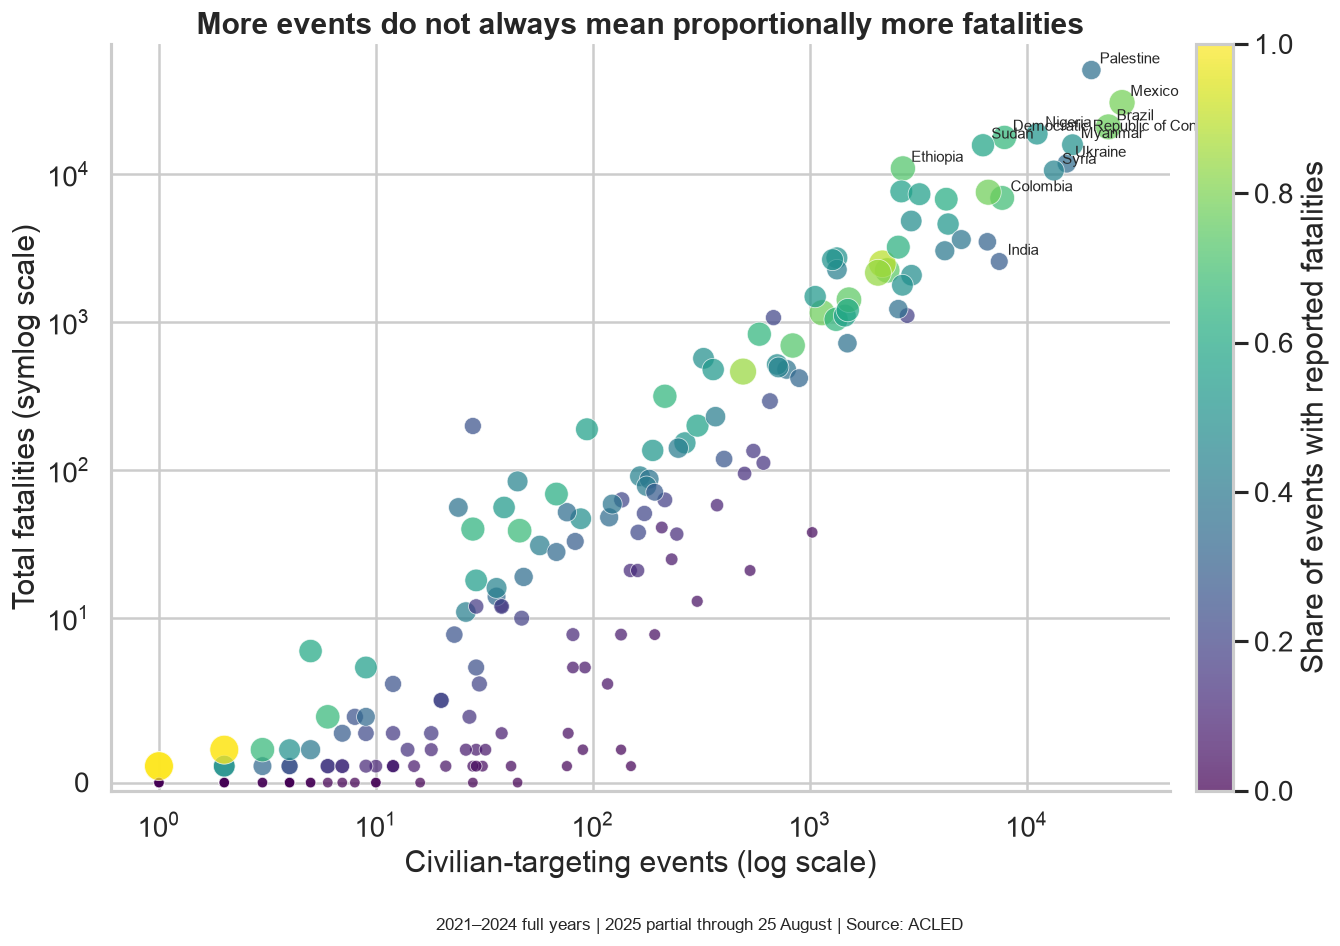

In [12]:
label_countries = set(country_summary.nlargest(10, "events")["country"]) | set(
    country_summary.nlargest(10, "total_fatalities")["country"]
)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    country_summary["events"], country_summary["total_fatalities"],
    s=40 + 260 * country_summary["lethality_rate"],
    c=country_summary["lethality_rate"], cmap="viridis",
    alpha=0.72, edgecolor="white", linewidth=0.5,
)
for row in country_summary.loc[country_summary["country"].isin(label_countries)].itertuples():
    ax.annotate(row.country, (row.events, row.total_fatalities), xytext=(5, 4), textcoords="offset points", fontsize=9)
ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=10)
ax.set_ylim(bottom=-0.5, top=country_summary["total_fatalities"].max() * 1.5)
ax.set(
    title="More events do not always mean proportionally more fatalities",
    xlabel="Civilian-targeting events (log scale)",
    ylabel="Total fatalities (symlog scale)",
)
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Share of events with reported fatalities")
fig.text(0.5, 0.01, "2021–2024 full years | 2025 partial through 25 August | Source: ACLED", ha="center", fontsize=10)
fig.tight_layout(rect=[0, 0.03, 1, 1])
save_figure(fig, "05_country_frequency_vs_fatalities")
plt.show()

### Commento ai risultati

Eventi e fatalità sono fortemente associati: la correlazione di rango è circa **0,92**, quindi i paesi con molti eventi tendono anche ad avere più fatalità riportate. La relazione, però, non è proporzionale. **Mexico** ha il maggior numero di eventi (27.553), mentre **Palestine** registra il maggior numero di fatalità (50.602) pur avendo meno eventi (19.903). Democratic Republic of Congo e Nigeria mostrano inoltre un impatto letale relativamente alto rispetto al loro numero di eventi.

**Interpretazione corretta:** frequenza e gravità descrivono due aspetti diversi. La correlazione non implica causalità e la media può essere influenzata da pochi eventi estremi; per questo il notebook mostra anche mediana, quota di eventi con almeno una fatalità riportata e massimo. Uno zero ACLED significa che non è stata riportata una fatalità quantificabile, non necessariamente che possiamo escludere ogni morte. I totali cumulativi includono il 2025 soltanto fino al 25 agosto.

## 5. RQ3 — Quali tipi di evento sono più frequenti e più letali?

Confrontiamo prima le quattro categorie principali e poi i sottotipi. Le fatalità restano associate all'intero evento ACLED.

In [13]:
event_type_summary = (
    analysis_df.groupby("event_type", observed=True)
    .agg(
        events=("event_id_cnty", "size"),
        fatalities=("fatalities", "sum"),
        mean_fatalities=("fatalities", "mean"),
        median_fatalities=("fatalities", "median"),
        fatal_events=("event_had_fatalities", "sum"),
    )
    .sort_values("events", ascending=False)
    .reset_index()
)
event_type_summary["event_share_pct"] = 100 * event_type_summary["events"] / event_type_summary["events"].sum()
event_type_summary["fatality_share_pct"] = 100 * event_type_summary["fatalities"] / event_type_summary["fatalities"].sum()
event_type_summary["lethality_rate_pct"] = 100 * event_type_summary["fatal_events"] / event_type_summary["events"]
display(event_type_summary)
event_type_summary.to_csv(TABLE_DIR / "event_type_summary.csv", index=False)

,event_type,events,fatalities,mean_fatalities,median_fatalities,fatal_events,event_share_pct,fatality_share_pct,lethality_rate_pct
0,Violence against civilians,177606,204822,1.15,1.00,107706,70.60,67.38,60.64
1,Explosions/Remote violence,45502,89739,1.97,0.00,21631,18.09,29.52,47.54
2,Riots,26492,7683,0.29,0.00,5738,10.53,2.53,21.66
3,Protests,1979,1724,0.87,0.00,694,0.79,0.57,35.07


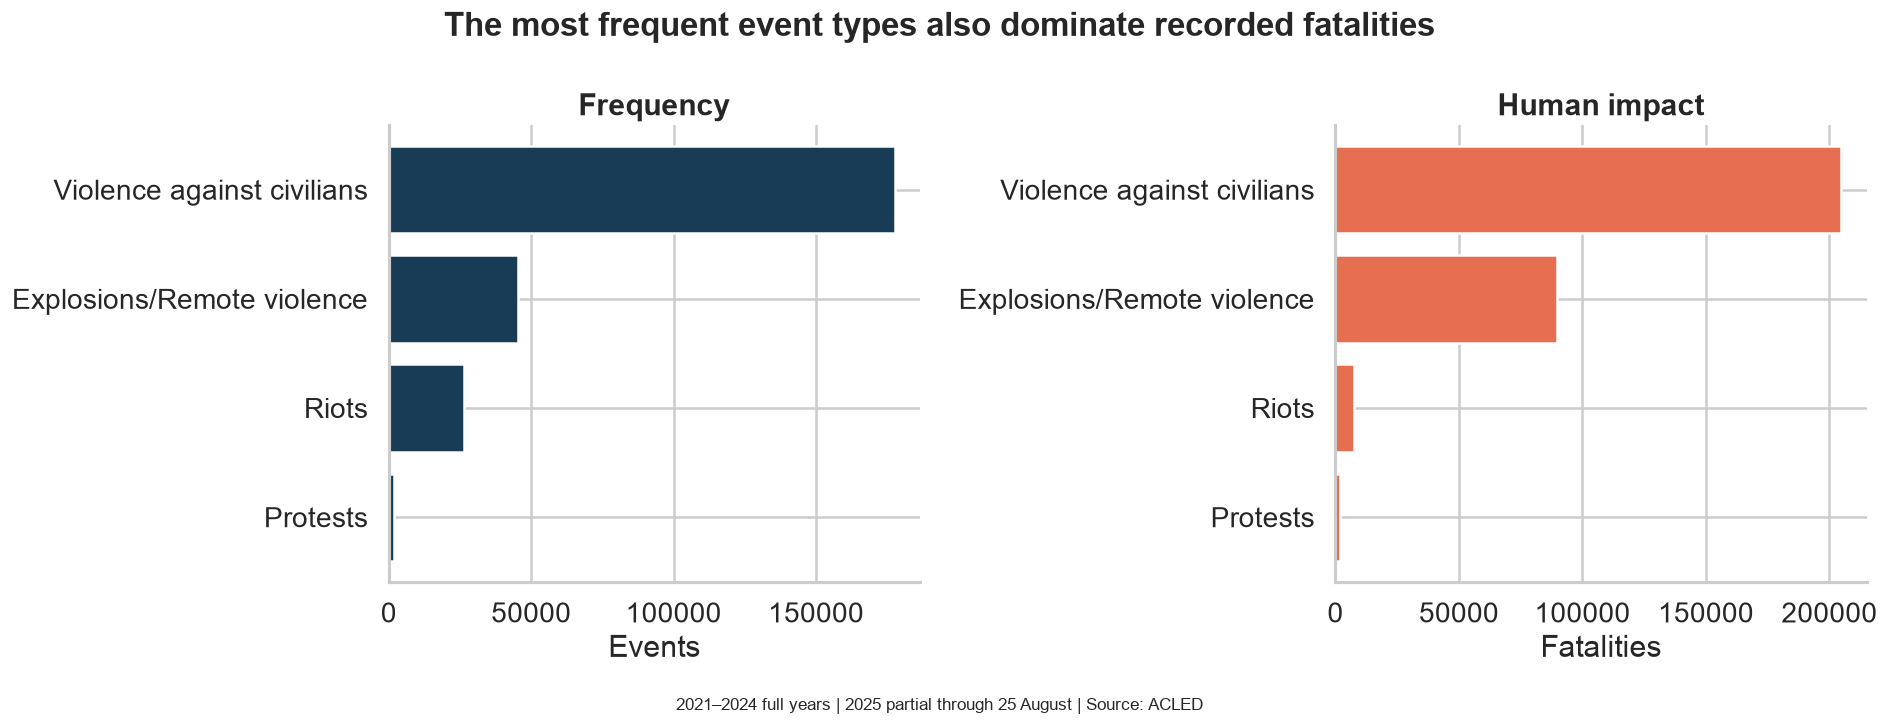

In [14]:
event_plot = event_type_summary.sort_values("events")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(event_plot["event_type"], event_plot["events"], color=NAVY)
axes[0].set(title="Frequency", xlabel="Events", ylabel="")

fatality_plot = event_type_summary.sort_values("fatalities")
axes[1].barh(fatality_plot["event_type"], fatality_plot["fatalities"], color=CORAL)
axes[1].set(title="Human impact", xlabel="Fatalities", ylabel="")
fig.suptitle("The most frequent event types also dominate recorded fatalities", fontsize=20, fontweight="bold")
fig.text(0.5, 0.01, "2021–2024 full years | 2025 partial through 25 August | Source: ACLED", ha="center", fontsize=10)
fig.tight_layout(rect=[0, 0.03, 1, 1])
save_figure(fig, "06_event_type_frequency_impact")
plt.show()

,event_type,sub_event_type,events,fatalities,mean_fatalities,fatal_events,lethality_rate
9,Violence against civilians,Attack,147609,202605,1.37,107141,0.73
0,Explosions/Remote violence,Air/drone strike,18648,60629,3.25,10043,0.54
4,Explosions/Remote violence,Shelling/artillery/missile attack,16143,18210,1.13,6705,0.42
3,Explosions/Remote violence,Remote explosive/landmine/IED,9634,8903,0.92,4532,0.47
7,Riots,Mob violence,26492,7683,0.29,5738,0.22
10,Violence against civilians,Sexual violence,2595,2217,0.85,565,0.22
6,Protests,Excessive force against protesters,1979,1724,0.87,694,0.35
5,Explosions/Remote violence,Suicide bomb,91,1476,16.22,91,1.00
2,Explosions/Remote violence,Grenade,984,521,0.53,260,0.26
1,Explosions/Remote violence,Chemical weapon,2,0,0.00,0,0.00


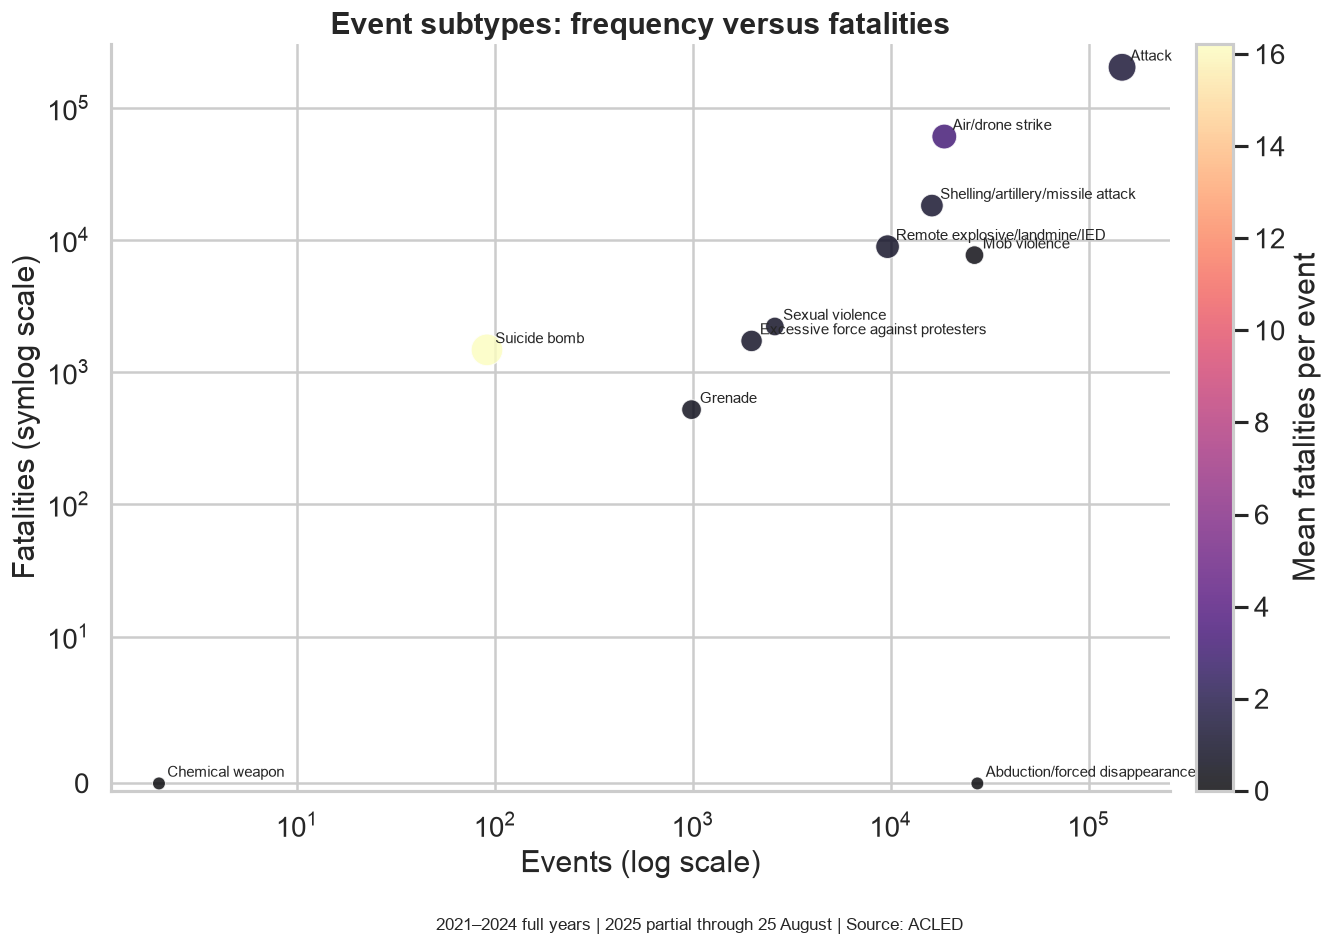

In [15]:
sub_event_summary = (
    analysis_df.groupby(["event_type", "sub_event_type"], observed=True)
    .agg(
        events=("event_id_cnty", "size"),
        fatalities=("fatalities", "sum"),
        mean_fatalities=("fatalities", "mean"),
        fatal_events=("event_had_fatalities", "sum"),
    )
    .reset_index()
)
sub_event_summary["lethality_rate"] = sub_event_summary["fatal_events"] / sub_event_summary["events"]
sub_event_summary.to_csv(TABLE_DIR / "sub_event_type_summary.csv", index=False)
display(sub_event_summary.sort_values("fatalities", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    sub_event_summary["events"], sub_event_summary["fatalities"],
    s=60 + 300 * sub_event_summary["lethality_rate"],
    c=sub_event_summary["mean_fatalities"], cmap="magma",
    alpha=0.8, edgecolor="white", linewidth=0.6,
)
for row in sub_event_summary.itertuples():
    ax.annotate(row.sub_event_type, (row.events, row.fatalities), xytext=(5, 4), textcoords="offset points", fontsize=9)
ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=10)
ax.set_ylim(bottom=-0.5, top=sub_event_summary["fatalities"].max() * 1.5)
ax.set(title="Event subtypes: frequency versus fatalities", xlabel="Events (log scale)", ylabel="Fatalities (symlog scale)")
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Mean fatalities per event")
fig.text(0.5, 0.01, "2021–2024 full years | 2025 partial through 25 August | Source: ACLED", ha="center", fontsize=10)
fig.tight_layout(rect=[0, 0.03, 1, 1])
save_figure(fig, "07_subevent_frequency_impact")
plt.show()

### Commento ai risultati

**Violence against civilians** domina sia per frequenza sia per fatalità: rappresenta il 70,6% degli eventi e il 67,4% delle fatalità riportate. **Explosions/Remote violence** costituisce il 18,1% degli eventi, ma il 29,5% delle fatalità e ha una media più alta (1,97 per evento): il suo peso letale è quindi sproporzionato rispetto alla frequenza. Tra i sottotipi, `Attack` concentra gran parte del volume; gli `Air/drone strike` registrano 60.629 fatalità in 18.648 eventi. I `Suicide bomb` sono rari (91 eventi), ma hanno la media più alta, circa 16,2 fatalità per evento.

**Interpretazione corretta:** i sottotipi meno frequenti possono essere molto più letali, ma la media dei gruppi piccoli è instabile. Inoltre le fatalità non rappresentano tutto il danno umano: abductions e sexual violence possono avere conseguenze gravissime anche quando ACLED registra zero morti. Non bisogna quindi usare le sole fatalità come classifica completa della sofferenza prodotta. Anche questi totali includono il 2025 solo fino al 25 agosto.

## 6. RQ5 — Quali paesi mostrano il maggiore bisogno di attenzione dal punto di vista della protezione dei civili?

Confrontiamo due prospettive complementari:

- **Absolute burden:** dove si concentrano complessivamente eventi e fatalità riportate.
- **Population-adjusted exposure:** dove eventi e fatalità pesano maggiormente rispetto alla popolazione.

I due score usano ranghi percentili e pesi uguali, evitando di sommare direttamente grandezze con scale diverse:

$$Absolute\ burden = 0.5(E) + 0.5(F)$$

$$Population\ adjusted = 0.5(E_{rate}) + 0.5(F_{rate})$$

La popolazione annuale proviene dal World Bank indicator [`SP.POP.TOTL`](https://data.worldbank.org/indicator/SP.POP.TOTL). I tassi dell'intero periodo usano **person-years di esposizione**: quattro anni completi più la quota osservata del 2025. In questo modo il 2025 parziale contribuisce sia al numeratore sia al denominatore in proporzione alla sua durata.

In [16]:
WORLD_BANK_API = "https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL"
POPULATION_PATH = EXTERNAL_DIR / "world_bank_population_2021_2025.csv"

if POPULATION_PATH.exists():
    population = pd.read_csv(POPULATION_PATH)
else:
    response = requests.get(
        WORLD_BANK_API,
        params={"format": "json", "date": "2021:2025", "per_page": 20_000},
        timeout=60,
    )
    response.raise_for_status()
    metadata, records = response.json()
    population = pd.DataFrame([
        {
            "population_iso3": record["countryiso3code"],
            "world_bank_country": record["country"]["value"],
            "year": int(record["date"]),
            "population": record["value"],
            "source_last_updated": metadata["lastupdated"],
        }
        for record in records if record["value"] is not None
    ])
    population.to_csv(POPULATION_PATH, index=False)

population["year"] = pd.to_numeric(population["year"], errors="raise").astype(int)
population["population"] = pd.to_numeric(population["population"], errors="coerce")
population_countries = population.loc[
    population["population_iso3"].notna() & population["population_iso3"].astype(str).str.len().eq(3)
].copy()
print(f"World Bank population observations: {len(population):,}")
print(f"Source last updated: {population['source_last_updated'].iloc[0]}")

# Crea una griglia completa paese × anno: un anno senza eventi deve contare come zero.
country_year_events = (
    analysis_df.groupby(["region", "country", "iso3", "year"], observed=True, dropna=False)
    .agg(events=("event_id_cnty", "size"), fatalities=("fatalities", "sum"))
    .reset_index()
)
country_keys = country_summary[["region", "country", "iso3"]].copy()
year_grid = pd.DataFrame({"year": range(2021, 2026)})
year_grid["exposure_fraction"] = 1.0
year_grid.loc[year_grid["year"].eq(partial_year), "exposure_fraction"] = partial_year_fraction
country_year = (
    country_keys.merge(year_grid, how="cross")
    .merge(country_year_events, on=["region", "country", "iso3", "year"], how="left")
)
country_year[["events", "fatalities"]] = country_year[["events", "fatalities"]].fillna(0)
country_year["population_iso3"] = country_year["iso3"].astype("string")
country_year.loc[country_year["country"].eq("Kosovo"), "population_iso3"] = "XKX"
country_year = country_year.merge(
    population_countries[["population_iso3", "year", "population"]],
    on=["population_iso3", "year"], how="left",
)

population_audit = (
    country_year.groupby(["country", "region"], observed=True, dropna=False)
    .agg(population_years_available=("population", "count"))
    .reset_index()
)
population_audit["complete_2021_2025"] = population_audit["population_years_available"].eq(5)
display(population_audit.loc[~population_audit["complete_2021_2025"]])

country_year["population_exposure"] = country_year["population"] * country_year["exposure_fraction"]
country_year["events_per_million_person_years"] = (
    country_year["events"] / country_year["population_exposure"] * 1_000_000
)
country_year["fatalities_per_million_person_years"] = (
    country_year["fatalities"] / country_year["population_exposure"] * 1_000_000
)
population_adjusted = (
    country_year.groupby(["region", "country", "iso3"], observed=True, dropna=False)
    .agg(
        population_years_available=("population", "count"),
        mean_population=("population", "mean"),
        population_exposure=("population_exposure", "sum"),
        period_events=("events", "sum"),
        period_fatalities=("fatalities", "sum"),
    )
    .reset_index()
)
population_adjusted["events_per_million_person_years"] = (
    population_adjusted["period_events"] / population_adjusted["population_exposure"] * 1_000_000
)
population_adjusted["fatalities_per_million_person_years"] = (
    population_adjusted["period_fatalities"] / population_adjusted["population_exposure"] * 1_000_000
)
protection_priority = country_summary.merge(
    population_adjusted, on=["region", "country", "iso3"], how="left"
)
priority_comparison = protection_priority.loc[
    protection_priority["population_years_available"].eq(5)
].copy()

for metric in ["events", "total_fatalities", "events_per_million_person_years", "fatalities_per_million_person_years"]:
    priority_comparison[f"{metric}_percentile"] = priority_comparison[metric].rank(method="average", pct=True)
priority_comparison["absolute_burden_score"] = 100 * (
    0.5 * priority_comparison["events_percentile"]
    + 0.5 * priority_comparison["total_fatalities_percentile"]
)
priority_comparison["population_adjusted_score"] = 100 * (
    0.5 * priority_comparison["events_per_million_person_years_percentile"]
    + 0.5 * priority_comparison["fatalities_per_million_person_years_percentile"]
)
priority_comparison["absolute_rank"] = priority_comparison["absolute_burden_score"].rank(
    method="min", ascending=False
).astype(int)
priority_comparison["population_adjusted_rank"] = priority_comparison["population_adjusted_score"].rank(
    method="min", ascending=False
).astype(int)
priority_comparison["rank_gain_when_adjusted"] = (
    priority_comparison["absolute_rank"] - priority_comparison["population_adjusted_rank"]
)

absolute_median = priority_comparison["absolute_burden_score"].median()
adjusted_median = priority_comparison["population_adjusted_score"].median()
priority_comparison["priority_profile"] = np.select(
    [
        priority_comparison["absolute_burden_score"].ge(absolute_median) & priority_comparison["population_adjusted_score"].ge(adjusted_median),
        priority_comparison["absolute_burden_score"].ge(absolute_median),
        priority_comparison["population_adjusted_score"].ge(adjusted_median),
    ],
    ["High on both", "High absolute burden", "High population-adjusted exposure"],
    default="Below median on both",
)

population_audit.to_csv(TABLE_DIR / "population_merge_audit.csv", index=False)
country_year.to_csv(TABLE_DIR / "country_year_population_adjusted.csv", index=False)
priority_comparison.to_csv(TABLE_DIR / "country_absolute_vs_population_adjusted.csv", index=False)

display(priority_comparison.nsmallest(15, "absolute_rank")[[
    "absolute_rank", "country", "events", "total_fatalities", "absolute_burden_score"
]])
display(priority_comparison.nsmallest(15, "population_adjusted_rank")[[
    "population_adjusted_rank", "country", "events_per_million_person_years",
    "fatalities_per_million_person_years", "population_adjusted_score"
]])

World Bank population observations: 1,320
Source last updated: 2026-07-13


,country,region,population_years_available,complete_2021_2025
1,Akrotiri and Dhekelia,Europe,0,False
5,Anguilla,Caribbean,0,False
59,French Guiana,South America,0,False
67,Guadeloupe,Caribbean,0,False
77,Indian Ocean,International Waters,0,False
105,Martinique,Caribbean,0,False
108,Mayotte,Eastern Africa,0,False
109,Mediterranean Sea,International Waters,0,False
140,Reunion,Eastern Africa,0,False
167,Taiwan,East Asia,0,False


,absolute_rank,country,events,total_fatalities,absolute_burden_score
121,1,Mexico,27553,30489,99.72
114,2,Palestine,19903,50602,99.44
140,3,Brazil,23830,20893,99.17
163,4,Myanmar,16282,15830,97.78
186,5,Nigeria,11166,18734,97.50
94,6,Ukraine,15310,11826,96.94
102,6,Democratic Republic of Congo,7908,17741,96.94
116,8,Syria,13360,10596,96.11
127,9,Sudan,6295,15702,95.00
142,10,Colombia,7721,6917,94.17


,population_adjusted_rank,country,events_per_million_person_years,fatalities_per_million_person_years,population_adjusted_score
114,1,Palestine,831.49,"2,114.02",100.00
15,2,Trinidad and Tobago,208.11,164.53,99.44
116,3,Syria,122.58,97.22,98.06
52,4,South Sudan,80.07,127.43,97.78
9,5,Jamaica,86.45,87.82,96.94
25,5,Belize,139.94,80.49,96.94
143,7,Ecuador,79.76,90.55,96.67
100,8,Central African Republic,55.00,112.18,96.39
8,9,Haiti,54.41,89.43,95.28
94,10,Ukraine,82.20,63.49,95.00


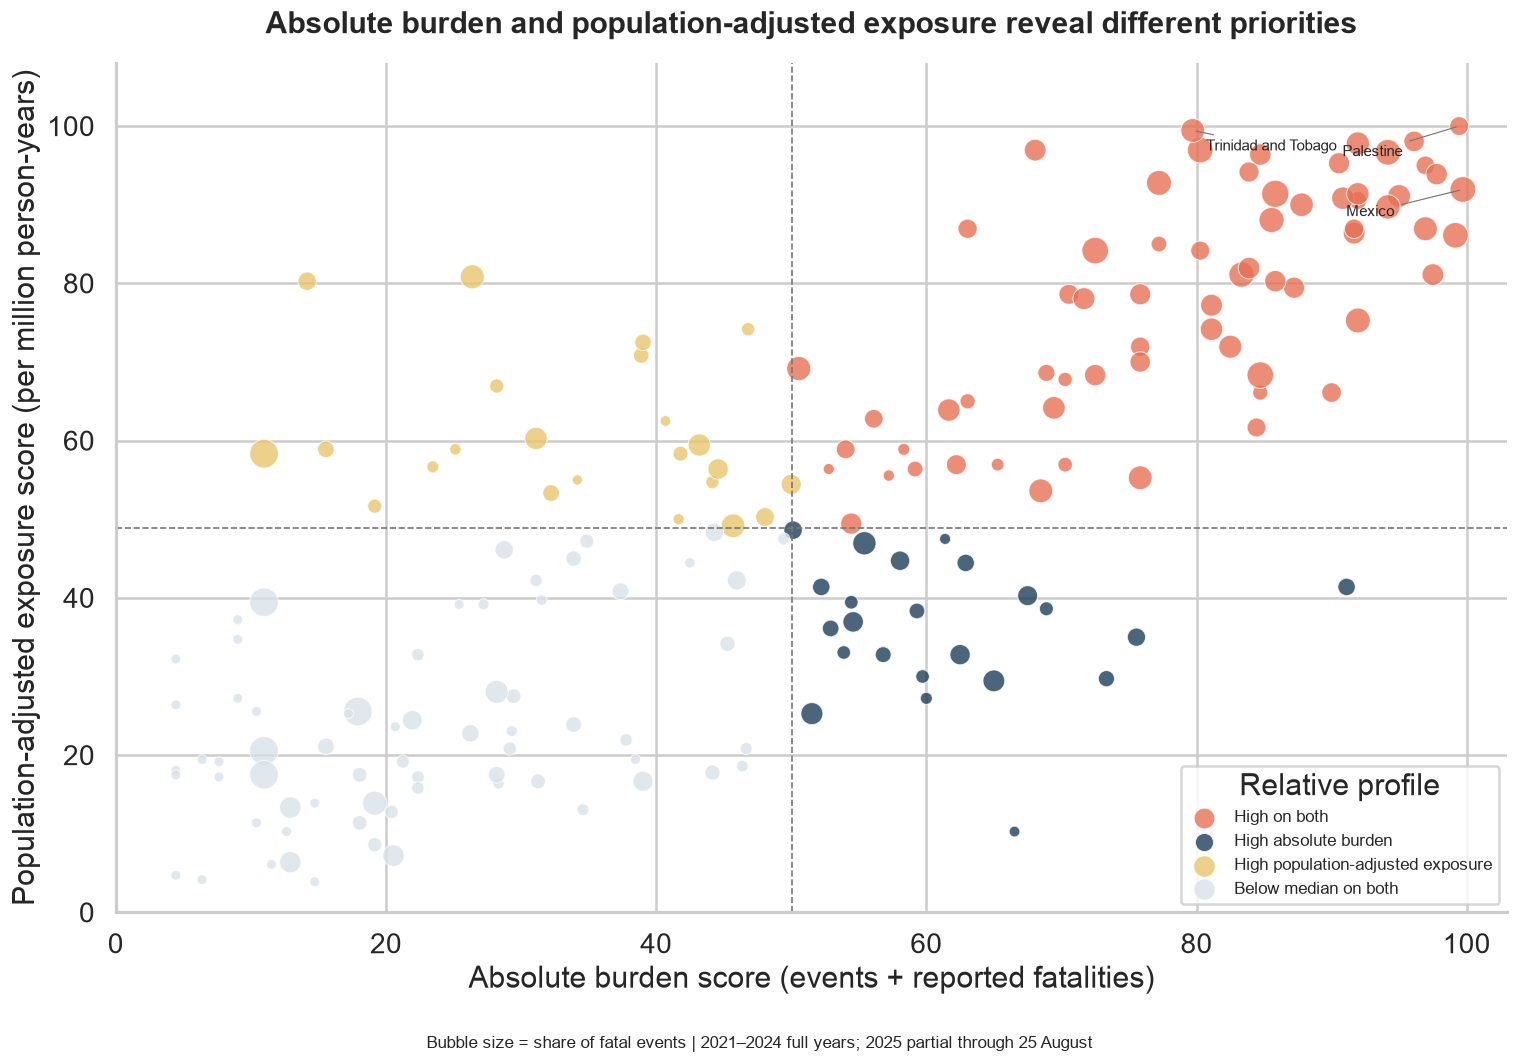

In [17]:
profile_colors = {
    "High on both": CORAL,
    "High absolute burden": NAVY,
    "High population-adjusted exposure": GOLD,
    "Below median on both": LIGHT_GREY,
}
label_countries = (
    set(priority_comparison.nsmallest(1, "absolute_rank")["country"])
    | set(priority_comparison.nsmallest(2, "population_adjusted_rank")["country"])
)
label_offsets = {
    "Mexico": (-70, -16), "Palestine": (-70, -18),
    "Trinidad and Tobago": (8, -12),
}

fig, ax = plt.subplots(figsize=(13, 9))
for profile, color in profile_colors.items():
    group = priority_comparison.loc[priority_comparison["priority_profile"].eq(profile)]
    ax.scatter(
        group["absolute_burden_score"], group["population_adjusted_score"],
        s=35 + 260 * group["lethality_rate"], color=color, label=profile,
        alpha=0.78, edgecolor="white", linewidth=0.6,
    )
for row in priority_comparison.loc[priority_comparison["country"].isin(label_countries)].itertuples():
    ax.annotate(
        row.country, (row.absolute_burden_score, row.population_adjusted_score),
        xytext=label_offsets.get(row.country, (7, 5)), textcoords="offset points", fontsize=9,
        arrowprops={"arrowstyle": "-", "color": "#777777", "lw": 0.7},
    )
ax.axvline(absolute_median, color="#777777", linestyle="--", linewidth=1)
ax.axhline(adjusted_median, color="#777777", linestyle="--", linewidth=1)
ax.set(
    title="Absolute burden and population-adjusted exposure reveal different priorities",
    xlabel="Absolute burden score (events + reported fatalities)",
    ylabel="Population-adjusted exposure score (per million person-years)",
    xlim=(0, 103), ylim=(0, 108),
)
ax.set_title("Absolute burden and population-adjusted exposure reveal different priorities", pad=18)
ax.legend(title="Relative profile", loc="lower right", frameon=True, fontsize=10)
fig.text(0.5, 0.01, "Bubble size = share of fatal events | 2021–2024 full years; 2025 partial through 25 August", ha="center", fontsize=10)
fig.tight_layout(rect=[0, 0.03, 1, 1])
save_figure(fig, "08_absolute_vs_population_adjusted")
plt.show()

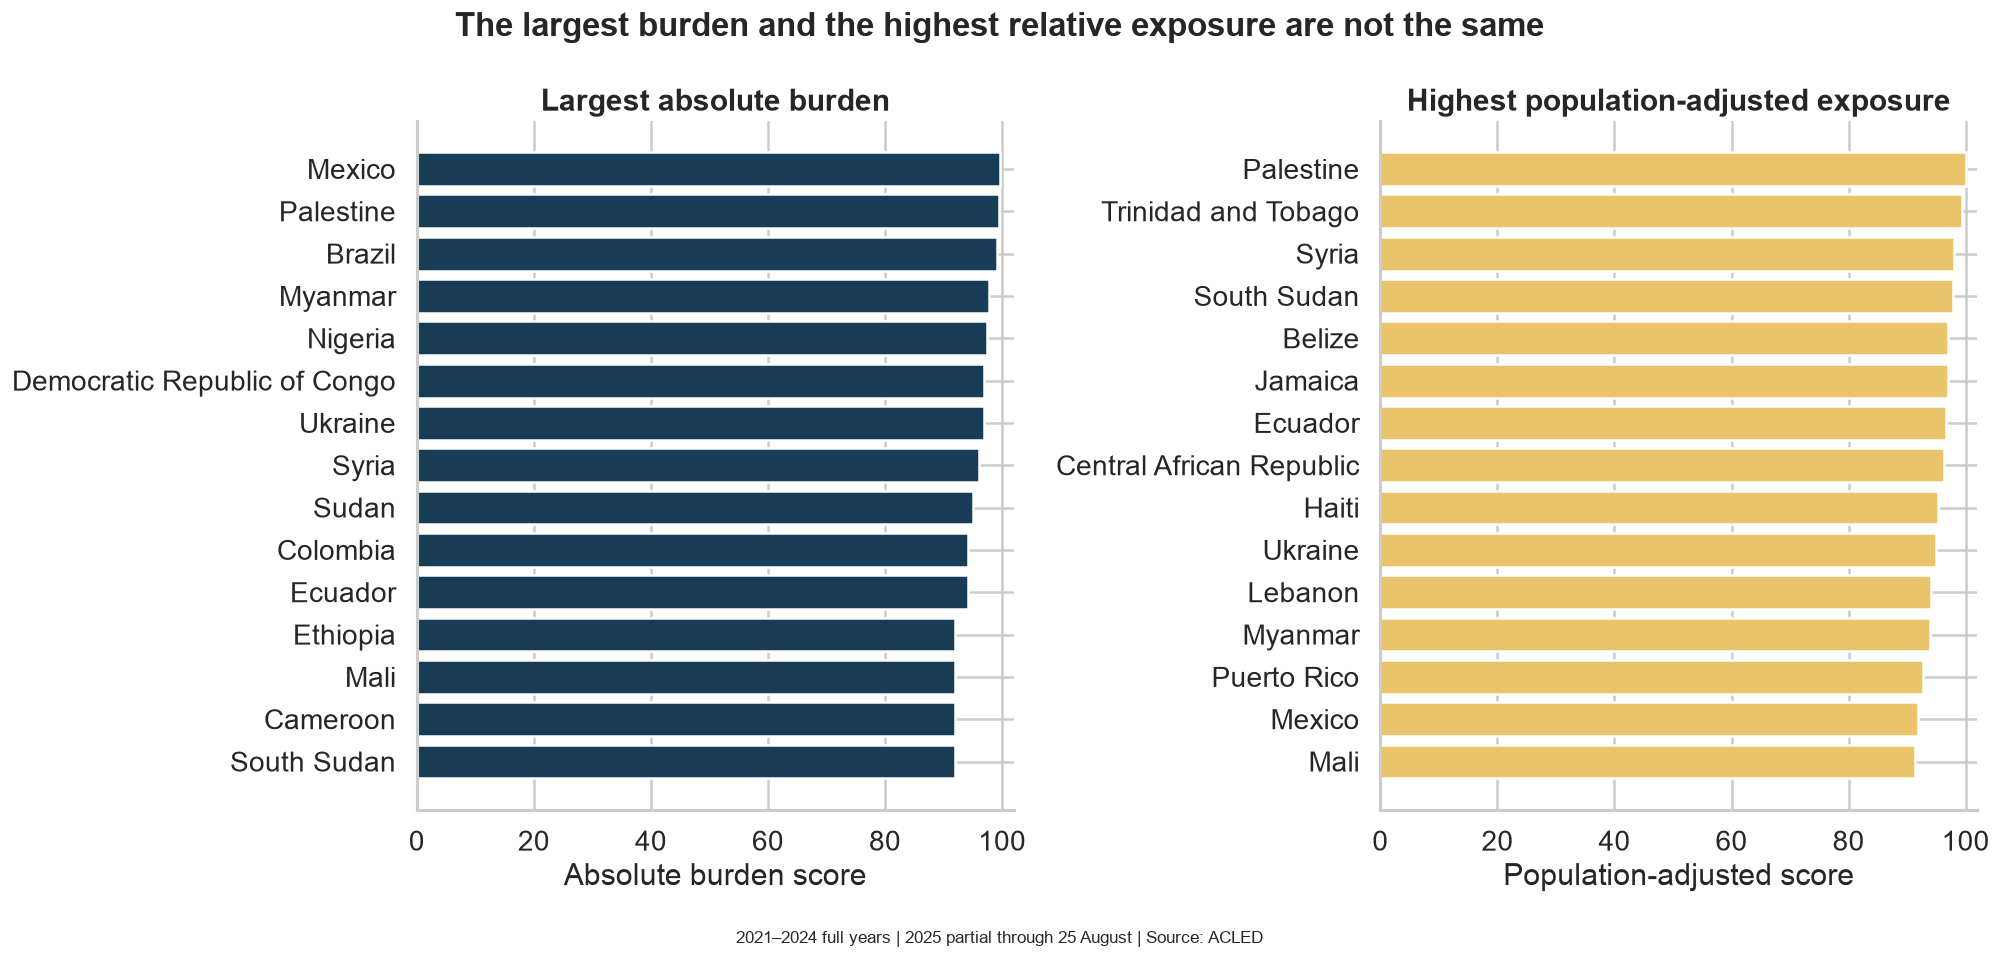

In [18]:
top_absolute = priority_comparison.nsmallest(15, "absolute_rank").sort_values("absolute_burden_score")
top_adjusted = priority_comparison.nsmallest(15, "population_adjusted_rank").sort_values("population_adjusted_score")

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
axes[0].barh(top_absolute["country"], top_absolute["absolute_burden_score"], color=NAVY)
axes[0].set(title="Largest absolute burden", xlabel="Absolute burden score", ylabel="", xlim=(0, 102))
axes[1].barh(top_adjusted["country"], top_adjusted["population_adjusted_score"], color=GOLD)
axes[1].set(title="Highest population-adjusted exposure", xlabel="Population-adjusted score", ylabel="", xlim=(0, 102))
fig.suptitle("The largest burden and the highest relative exposure are not the same", fontsize=20, fontweight="bold")
fig.text(0.5, 0.01, "2021–2024 full years | 2025 partial through 25 August | Source: ACLED", ha="center", fontsize=10)
fig.tight_layout(rect=[0, 0.03, 1, 1])
save_figure(fig, "09_absolute_vs_adjusted_rankings")
plt.show()

### Controllo metodologico

Verifichiamo copertura demografica, corrispondenza paese-anno, quota temporale osservata nel 2025 e differenza effettiva tra i due ranking. Le unità senza cinque anni di popolazione restano nell'analisi assoluta, ma non entrano nel confronto population-adjusted.

In [19]:
excluded_units = protection_priority.loc[
    ~protection_priority["population_years_available"].eq(5),
    ["country", "region", "population_years_available"],
].copy()
top15_absolute = set(priority_comparison.nsmallest(15, "absolute_rank")["country"])
top15_adjusted = set(priority_comparison.nsmallest(15, "population_adjusted_rank")["country"])
ranking_correlation = priority_comparison["absolute_rank"].corr(
    priority_comparison["population_adjusted_rank"]
)
methodology_audit = pd.DataFrame({
    "check": [
        "ACLED country/territory units",
        "units with complete population 2021-2025",
        "units excluded from adjusted comparison",
        "2025 observed fraction",
        "rank correlation: absolute vs adjusted",
        "countries shared by the two top 15 lists",
        "adjusted top 15 with fewer than 20 events",
    ],
    "value": [
        len(protection_priority), len(priority_comparison), len(excluded_units),
        partial_year_fraction,
        ranking_correlation, len(top15_absolute & top15_adjusted),
        int(priority_comparison.nsmallest(15, "population_adjusted_rank")["low_sample_flag"].sum()),
    ],
})
assert country_year["year"].nunique() == 5
assert country_year.loc[country_year["population"].notna(), "population"].gt(0).all()
assert country_year["exposure_fraction"].gt(0).all() and country_year["exposure_fraction"].le(1).all()
assert priority_comparison["population_years_available"].eq(5).all()
display(methodology_audit)
display(excluded_units)
methodology_audit.to_csv(TABLE_DIR / "priority_methodology_audit.csv", index=False)

,check,value
0,ACLED country/territory units,190.00
1,units with complete population 2021-2025,180.00
2,units excluded from adjusted comparison,10.00
3,2025 observed fraction,0.65
4,rank correlation: absolute vs adjusted,0.77
5,countries shared by the two top 15 lists,8.00
6,adjusted top 15 with fewer than 20 events,0.00


,country,region,population_years_available
0,Anguilla,Caribbean,0
7,Guadeloupe,Caribbean,0
10,Martinique,Caribbean,0
37,Taiwan,East Asia,0
47,Mayotte,Eastern Africa,0
49,Reunion,Eastern Africa,0
55,Akrotiri and Dhekelia,Europe,0
96,Indian Ocean,International Waters,0
97,Mediterranean Sea,International Waters,0
144,French Guiana,South America,0


### Commento ai risultati

Il confronto produce due geografie diverse. In termini assoluti emergono soprattutto **Mexico**, **Palestine** e **Brazil**. Dopo la correzione per popolazione e durata osservata, **Palestine** passa al primo posto, seguita da **Trinidad and Tobago**, **Syria** e **South Sudan**. Al contrario, paesi molto popolosi come Brazil e Nigeria rimangono importanti per volume complessivo, ma scendono nel ranking population-adjusted.

Questa differenza è il risultato centrale: **dove si concentra il maggior numero di eventi e fatalità non coincide necessariamente con dove il peso sulla popolazione è più elevato**. La correlazione tra i due ranking è 0,77 e soltanto 8 paesi compaiono in entrambe le top 15. La classifica corretta per popolazione fa emergere anche paesi più piccoli che sarebbero poco visibili in un ranking di soli valori assoluti.

**Interpretazione corretta:** i tassi misurano eventi e fatalità registrati per milione di person-years, non la probabilità individuale di subire violenza. Il 2025 contribuisce per il 64,9% di un anno sia nei conteggi sia nel denominatore temporale. Il denominatore nazionale può comunque nascondere hotspot locali e il confronto non considera sfollamento, vulnerabilità, accesso agli aiuti o capacità istituzionale. Per questo il risultato va presentato come **ACLED-based population-adjusted exposure**, sempre accanto ai conteggi assoluti. Dieci unità senza copertura demografica completa sono documentate nell'audit ed escluse soltanto dal confronto corretto per popolazione.

## 7. Esportazione e insight automatici

I risultati aggregati vengono salvati separatamente dal dataset pulito. Gli insight stampati sono punti di partenza da verificare e contestualizzare nelle slide.

In [20]:
country_summary.to_csv(TABLE_DIR / "country_summary_available_period.csv", index=False)

top_region = region_total.index[0]
top_events_country = country_summary.nlargest(1, "events").iloc[0]
top_fatality_country = country_summary.nlargest(1, "total_fatalities").iloc[0]
top_absolute_country = priority_comparison.nsmallest(1, "absolute_rank").iloc[0]
top_adjusted_country = priority_comparison.nsmallest(1, "population_adjusted_rank").iloc[0]
top_event_type = event_type_summary.nlargest(1, "events").iloc[0]
top_fatality_type = event_type_summary.nlargest(1, "fatalities").iloc[0]
full_years = global_year.loc[global_year["year"].lt(partial_year)]
event_change_2021_2024 = 100 * (full_years.iloc[-1]["events"] / full_years.iloc[0]["events"] - 1)
fatality_change_2021_2024 = 100 * (full_years.iloc[-1]["fatalities"] / full_years.iloc[0]["fatalities"] - 1)

print("INSIGHT CHECKLIST")
print(f"• Across full years 2021–2024, global events changed by {event_change_2021_2024:+.1f}%.")
print(f"• Across full years 2021–2024, recorded fatalities changed by {fatality_change_2021_2024:+.1f}%.")
print(f"• 2025 is partial through {analysis_end_date:%d %B}: {global_year.iloc[-1]['events']:,} events recorded so far.")
print(f"• Region with most events across the available 2021–2025 period: {top_region}.")
print(f"• Country with most events: {top_events_country['country']} ({top_events_country['events']:,}).")
print(f"• Country with most fatalities: {top_fatality_country['country']} ({top_fatality_country['total_fatalities']:,}).")
print(f"• Most frequent event type: {top_event_type['event_type']}.")
print(f"• Event type with most fatalities: {top_fatality_type['event_type']}.")
print(f"• Highest absolute burden score: {top_absolute_country['country']} ({top_absolute_country['absolute_burden_score']:.1f}/100).")
print(f"• Highest population-adjusted exposure: {top_adjusted_country['country']} ({top_adjusted_country['population_adjusted_score']:.1f}/100).")
print(f"\nTables: {TABLE_DIR}")
print(f"Figures: {FIGURE_DIR}")

INSIGHT CHECKLIST
• Across full years 2021–2024, global events changed by +45.0%.
• Across full years 2021–2024, recorded fatalities changed by +76.9%.
• 2025 is partial through 25 August: 43,797 events recorded so far.
• Region with most events across the available 2021–2025 period: Middle East.
• Country with most events: Mexico (27,553).
• Country with most fatalities: Palestine (50,602).
• Most frequent event type: Violence against civilians.
• Event type with most fatalities: Violence against civilians.
• Highest absolute burden score: Mexico (99.7/100).
• Highest population-adjusted exposure: Palestine (100.0/100).

Tables: /Users/nicole/Desktop/projects/datavis/data/analysis
Figures: /Users/nicole/Desktop/projects/datavis/outputs/eda_figures


### Regole di interpretazione per le slide

1. Scrivere sempre **recorded fatalities in civilian-targeting events**, non automaticamente *civilian deaths*.
2. Dichiarare sempre: **2021–2024 full years; 2025 partial through 25 August**.
3. Mostrare sempre absolute burden e population-adjusted exposure insieme.
4. Chiamare i tassi **recorded events/fatalities per million person-years**, non rischio individuale.
5. Segnalare paesi/territori esclusi per mancanza di popolazione e risultati basati su pochi eventi.
6. Evitare causalità: questa EDA descrive concentrazione, andamento e associazioni.
7. Il denominatore population-adjusted usa quattro anni completi più la frazione osservata del 2025; i due score non includono sfollamento, vulnerabilità o capacità di risposta.